In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')
print("Notebook ready!")

Notebook ready!


In [2]:
from data_loader import load_data, create_target, handle_missing

df = load_data('../data/ADHD.xlsx')
df = create_target(df)
df = handle_missing(df)

# Quick check
df[['asrs_part_a', 'target']].head(10)

Data loaded successfully — 506 rows, 110 columns
Target created — ADHD Positive: 251, Negative: 255
Missing values handled successfully


,asrs_part_a,target
0,5,0
1,14,1
2,13,0
3,15,1
4,7,0
5,11,0
6,11,0
7,6,0
8,13,0
9,16,1


In [3]:
from feature_engineering import build_feature_matrix, check_class_imbalance
from model import split_data

# Build full feature matrix
X, vectorizer = build_feature_matrix(df)
y = df['target'].values

# Split BEFORE feature selection (very important)
X_train, X_test, y_train, y_test = split_data(X, y)

# Check class imbalance on training set
is_imbalanced = check_class_imbalance(y_train)

Numeric features selected: 20
Categorical features encoded: 4
TF-IDF features created: 100 words/phrases

Full feature matrix: 506 rows x 124 features
Training set : 404 rows
Testing set  : 102 rows

  CLASS IMBALANCE CHECK
  ADHD Negative (0) : 204 (50.5%)
  ADHD Positive (1) : 200 (49.5%)
  Imbalance ratio   : 1.020
  Status: BALANCED — no handling needed


In [3]:
from feature_engineering import (build_feature_matrix,
                                  check_class_imbalance,
                                  apply_feature_selection)
from model import split_data

X, vectorizer = build_feature_matrix(df)
y = df['target'].values

X_train, X_test, y_train, y_test = split_data(X, y)

is_imbalanced = check_class_imbalance(y_train)

Numeric features selected: 20
Categorical features encoded: 4
TF-IDF features created: 100 words/phrases

Full feature matrix: 506 rows x 124 features
Training set : 404 rows
Testing set  : 102 rows

  CLASS IMBALANCE CHECK
  ADHD Negative (0) : 204 (50.5%)
  ADHD Positive (1) : 200 (49.5%)
  Imbalance ratio   : 1.020
  Status: BALANCED — no handling needed


In [4]:
X_train_sel, X_test_sel, selector = apply_feature_selection(
    X_train, y_train, X_test, k=20
)


Applying feature selection...
  Features before selection : 124
  Features after selection  : 20
  Features removed          : 104


C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

In [5]:
from model import (train_logistic_regression, train_svm,
                   train_xgboost, train_mlp, train_stacking,
                   train_random_forest, save_model)

lr_model      = train_logistic_regression(X_train_sel, y_train)
svm_model     = train_svm(X_train_sel, y_train)
xgb_model     = train_xgboost(X_train_sel, y_train)
mlp_model     = train_mlp(X_train_sel, y_train)
stack_model   = train_stacking(X_train_sel, y_train)

save_model(lr_model,    'logistic_regression.pkl')
save_model(svm_model,   'svm.pkl')
save_model(xgb_model,   'xgboost.pkl')
save_model(mlp_model,   'mlp.pkl')
save_model(stack_model, 'stacking.pkl')

print("\nAll models trained and saved!")


Training Logistic Regression...
Done!

Training SVM (linear kernel)...
Done!

Training XGBoost...
Done!

Training MLP (Neural Network)...
Done!

Training Stacking Ensemble (LR + XGBoost)...
Done!
Saved: ../models\logistic_regression.pkl
Saved: ../models\svm.pkl
Saved: ../models\xgboost.pkl
Saved: ../models\mlp.pkl
Saved: ../models\stacking.pkl

All models trained and saved!



  Results for: Logistic Regression
  Accuracy  : 81.4%
  F1 Score  : 80.8%
  Precision : 83.3%
  Recall    : 78.4%
               precision    recall  f1-score   support

ADHD Negative       0.80      0.84      0.82        51
ADHD Positive       0.83      0.78      0.81        51

     accuracy                           0.81       102
    macro avg       0.81      0.81      0.81       102
 weighted avg       0.81      0.81      0.81       102



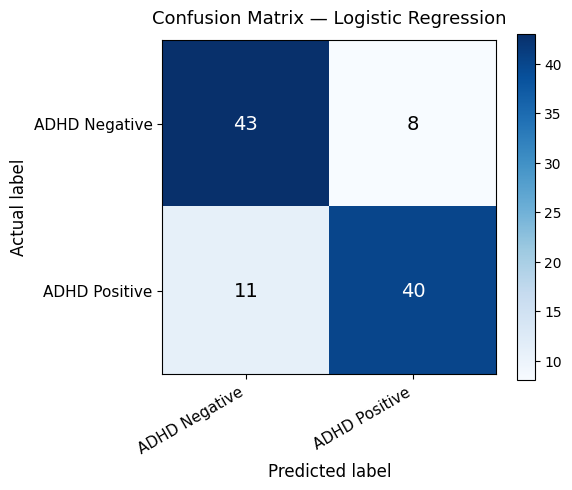


  Results for: SVM (Linear)
  Accuracy  : 81.4%
  F1 Score  : 80.4%
  Precision : 84.8%
  Recall    : 76.5%
               precision    recall  f1-score   support

ADHD Negative       0.79      0.86      0.82        51
ADHD Positive       0.85      0.76      0.80        51

     accuracy                           0.81       102
    macro avg       0.82      0.81      0.81       102
 weighted avg       0.82      0.81      0.81       102



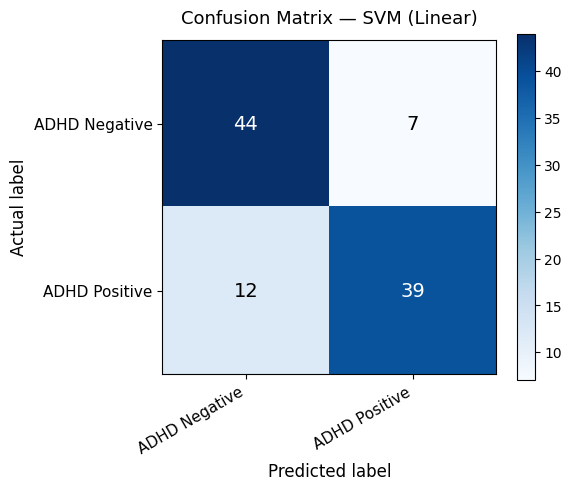


  Results for: XGBoost
  Accuracy  : 75.5%
  F1 Score  : 75.2%
  Precision : 76.0%
  Recall    : 74.5%
               precision    recall  f1-score   support

ADHD Negative       0.75      0.76      0.76        51
ADHD Positive       0.76      0.75      0.75        51

     accuracy                           0.75       102
    macro avg       0.76      0.75      0.75       102
 weighted avg       0.75      0.75      0.75       102



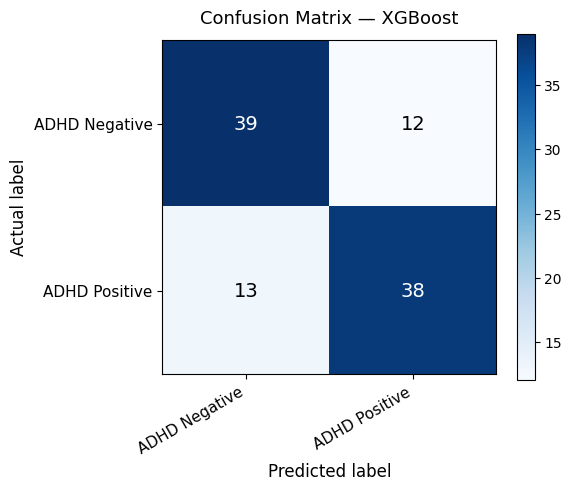


  Results for: MLP
  Accuracy  : 69.6%
  F1 Score  : 69.3%
  Precision : 70.0%
  Recall    : 68.6%
               precision    recall  f1-score   support

ADHD Negative       0.69      0.71      0.70        51
ADHD Positive       0.70      0.69      0.69        51

     accuracy                           0.70       102
    macro avg       0.70      0.70      0.70       102
 weighted avg       0.70      0.70      0.70       102



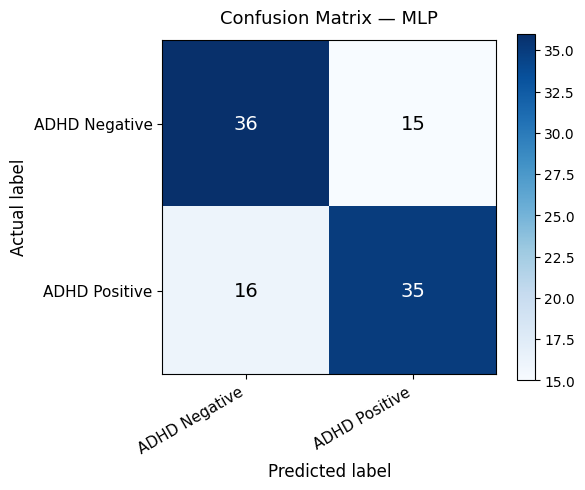


  Results for: Stacking (LR+XGB)
  Accuracy  : 81.4%
  F1 Score  : 80.0%
  Precision : 86.4%
  Recall    : 74.5%
               precision    recall  f1-score   support

ADHD Negative       0.78      0.88      0.83        51
ADHD Positive       0.86      0.75      0.80        51

     accuracy                           0.81       102
    macro avg       0.82      0.81      0.81       102
 weighted avg       0.82      0.81      0.81       102



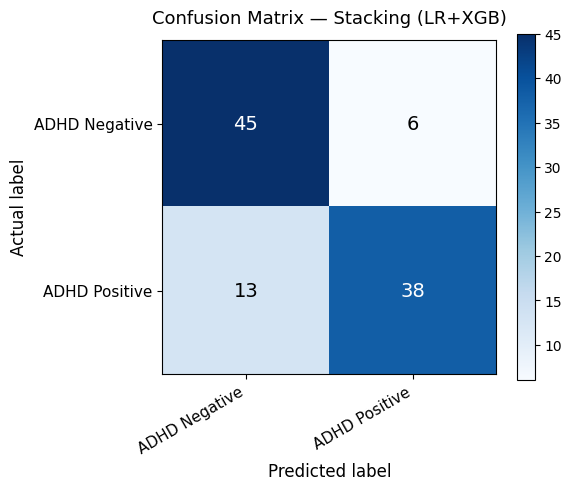

In [6]:
from evaluate import evaluate_model, plot_confusion_matrix

all_models = {
    "Logistic Regression" : lr_model,
    "SVM (Linear)"        : svm_model,
    "XGBoost"             : xgb_model,
    "MLP"                 : mlp_model,
    "Stacking (LR+XGB)"   : stack_model,
}

preds = {}
for name, model in all_models.items():
    preds[name] = evaluate_model(model, X_test_sel, y_test, name)
    plot_confusion_matrix(y_test, preds[name], name)

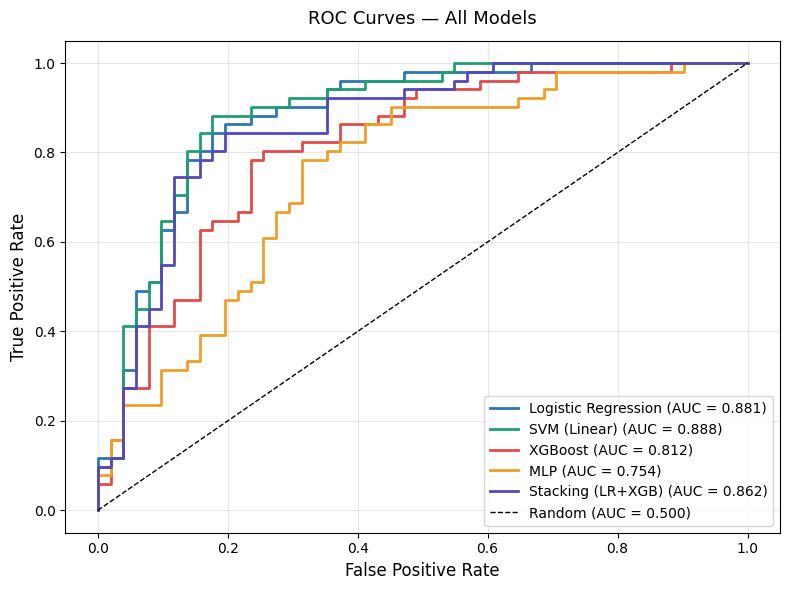

ROC curves saved to models/ folder


In [7]:
from evaluate import plot_roc_curves

plot_roc_curves(all_models, X_test_sel, y_test)

In [8]:
from evaluate import cross_validate_all

cross_validate_all(all_models, X_train_sel, y_train, cv=5)


  5-FOLD CROSS VALIDATION
  Model                     Mean F1    Std Dev
  --------------------------------------------
  Logistic Regression         76.5%       2.8%
  SVM (Linear)                74.9%       3.7%
  XGBoost                     71.8%       4.1%
  MLP                         70.6%       9.0%
  Stacking (LR+XGB)           73.5%       4.3%


In [9]:
from evaluate import compare_models

compare_models(all_models, X_test_sel, y_test)


  FINAL MODEL COMPARISON
  Model                    Accuracy       F1   Recall  Precision
  ----------------------------------------------------------
  Logistic Regression         81.4%    80.8%    78.4%      83.3%
  SVM (Linear)                81.4%    80.4%    76.5%      84.8%
  Stacking (LR+XGB)           81.4%    80.0%    74.5%      86.4%
  XGBoost                     75.5%    75.2%    74.5%      76.0%
  MLP                         69.6%    69.3%    68.6%      70.0%

  Best model: Logistic Regression (81.4% accuracy)
